# Constructing a noise Bbdget for the Einstein Telescope in Finesse3
Enzo Tapia, 15.06.2026

This file is part of the hands-on session during the Finesse workshop at the ET Symposium in Aachen.

This notebook provides a concise walkthrough for importing, tuning, and evaluating the sensitivity limits of the **Einstein Telescope Low-Frequency (ETLF)** and **High-Frequency (ETHF)** interferometers. Utilizing the updated framework of **Finesse3**, we simulate the instrument's optical response functions to assemble a comprehensive dual-detector noise budget.

In [16]:
# This code block is only needed on Google Colab, you don't need this
# when running the notebook locally, but it can be executed without 
# causing any problems.

# install pypi wheel only on google colab
!env | grep -q 'colab' && pip install finesse git+https://gitlab.com/ifosim/ifotools.git@dbb86e36512178b2e02096b8b54311bbfd1e282f || echo 'Not on google colab, assuming finesse already installed'

# transfer extra files from github repository 
import os, urllib.request
REPO = "https://github.com/gwoptics/finesse3_workshop" 
#"https://raw.githubusercontent.com/<you>/<repo>/<branch>"

def ensure(path):
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{REPO}/{path}", path)

# List all the files that the notebook expects to load
ASSETS = [
    'noise_model_files/ET_HF.kat',
    'noise_model_files/ET_LF.kat',
    ]

for f in ASSETS:
    ensure(f)


Not on google colab, assuming finesse already installed


In [17]:
import finesse
import finesse.analysis.actions as faa
from finesse.analysis.actions import NoiseProjection, Xaxis

finesse.init_plotting() 

import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [18]:
# Helper functions
def QNLS(mod,node="B1.p1.i"):
    temp = mod.deepcopy()
    #remove modulators: should not be not needed here, and produce noisy looking qnls >~kHz range
    mods = tuple(temp.get_elements_of_type(finesse.components.Modulator))
    for mod in mods:
        mod.order=0
    temp.parse(f"""
        fsig(1)
        sgen darmx LX.h
        sgen darmy LY.h phase=180
        qnoised QNLS {node} nsr=True
        """)
    out = temp.run('xaxis(darmx.f, "log", 2e-1, 5e3, 300)')
    return out.x1, np.abs(out['QNLS'])


def plot_QNLS(mod,node, ax=None, desc=None, **kwargs):
    if ax is None:
        fig,ax=plt.subplots()
        ax.set(xlabel='f [Hz]', ylabel='ASD [/sqrt(Hz)]', title=f'QNLS')
    
    oo=QNLS(mod,node)
    ax.loglog(oo[0],oo[1],label=desc, **kwargs)
    
    if desc:
        ax.legend(loc=2,bbox_to_anchor=(1,1))
    return ax

## 1. Importing the Pre-configured Optical Models
We instantiate individual Finesse models for the High-Frequency (`ETHF`) and Low-Frequency (`ETLF`) baseline instruments. These configurations are parsed from standard `.kat` files containing the core interferometer topologies (dual-recycled Fabry-Perot Michelson configurations), mirror substrate parameters, and initial cavity specifications.

In [19]:
ETHF = finesse.Model()
ETHF.parse_file("noise_model_files/ET_HF.kat");

In [20]:
ETLF = finesse.Model()
ETLF.parse_file("noise_model_files/ET_LF.kat");

### 1.1 Verifying Optical Configuration and Detuning Parameters
Before running the noise actions, we can directly inspect model attributes. For instance, checking the **Signal Recycling (SR) mirror detuning** in the ETLF model allows us to confirm the targeted optomechanical resonance profile (e.g., Detuned Resonant Sideband Extraction) defined within the baseline script.

In [21]:
ETLF.SRdetuning.value

17.2

## 2. Interferometer Initialization
For simplicity and to focus mainly on noise projections restrict our simulation to a plane-wave approximation. Thus, we disable the spatial mode configurations by setting `maxtem='off'`. This eliminates spatial beam operators and higher-order mode (HOM) expansion, resulting in a plane-wave model ideal for baseline noise budget.

In [22]:
print("=====LF, TUNED======")
ETLF_pw = ETLF.deepcopy()
ETLF_pw.modes('off') #plane-wave model

#HF
print("=====HF, TUNED======")
ETHF_pw = ETHF.deepcopy()
ETHF_pw.modes('off') #plane-wave model

=====LF, TUNED======
=====HF, TUNED======


## Here we show the Quantum Noise Limited Sensitivity (QNLS) of both detectors (HF and LF).

Note: Here the cavity lengths are at their nominal. Since the carrier field is no longer perfectly resonant or coupled as intended. Thus, the optomechanical spring frequency shifts and is visible in the plot.

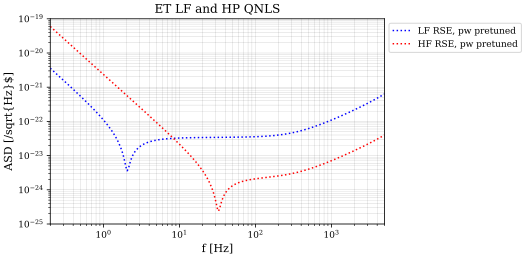

In [23]:
fig,ax = plt.subplots()
ax.set(xlabel='f [Hz]', ylabel='ASD [/sqrt{Hz}$]', title=f'ET LF and HP QNLS')

ax = plot_QNLS(ETLF_pw,node="BHDBS.p2.o",desc="LF RSE, pw pretuned", ax=ax, ls=':')
ax = plot_QNLS(ETHF_pw,node="BHDBS.p2.o",desc="HF RSE, pw pretuned", ax=ax, ls=':')
ax.set(ylim=(1e-25,1e-19));

The seismic displacement noise for the ETLF has been taken from ET-0007C-20, pages 136, 137.

For the ETHF the same seismic displacement noise for Virgo has been assumed.

In [24]:
ETLF1 = ETLF_pw.deepcopy()
ETLF1.parse('''
# Differential arm length degree of freedom (strain)
dof DARMh LX.dofs.h +1 LY.dofs.h -1

fsig(1)
# Seismic displacement noise on each test mass (m/rtHz)
noise seismic_ETMX ETMX.mech.z 1e-4/fsig**15/1e11 # extra factor of 1e-11 of attenuation. # from ET-0007C-20 pages 136, 137.
noise seismic_ETMY ETMY.mech.z 1e-4/fsig**15/1e11
noise seismic_ITMX ITMX.mech.z 1e-4/fsig**15/1e11
noise seismic_ITMY ITMY.mech.z 1e-4/fsig**15/1e11

readout_dc AS_port BHDBS.p2.o

# Quantum noise
qnoised qn BHDBS.p2.o
sgen sig1 LY.h 1 0
sgen sig2 LX.h 1 180
pd1 TF BHDBS.p2.o f=fsig.f

#Extra noises can be added here
''')


ETHF1 = ETHF_pw.deepcopy()
ETHF1.parse('''
# Differential arm length degree of freedom (strain)
dof DARMh LX.dofs.h +1 LY.dofs.h -1

fsig(1)
# Seismic displacement noise on each test mass (m/rtHz)
noise seismic_ETMX ETMX.mech.z 1e-4/fsig**15
noise seismic_ETMY ETMY.mech.z 1e-4/fsig**15
noise seismic_ITMX ITMX.mech.z 1e-4/fsig**15
noise seismic_ITMY ITMY.mech.z 1e-4/fsig**15

readout_dc AS_port BHDBS.p2.o

# Quantum noise
qnoised qn BHDBS.p2.o
sgen sig1 LY.h 1 0
sgen sig2 LX.h 1 180
pd1 TF BHDBS.p2.o f=fsig.f

# Coating thermal noise on each test mass (m/rtHz)
noise coating_ETMX ETMX.mech.z 4.64e-20/fsig**0.5
noise coating_ETMY ETMY.mech.z 4.64e-20/fsig**0.5
noise coating_ITMX ITMX.mech.z 4.64e-20/fsig**0.5
noise coating_ITMY ITMY.mech.z 4.64e-20/fsig**0.5

#Extra noises can be added here
''');

## 3. Simulating the Noise Projections
With the interferometers aligned and locked, we calculate how the internal noise spectral densities couple to the dark port strain signal ($h/\sqrt{\mathrm{Hz}}$). 

Classical noise projection scaled to strain via the DARMh dof. This is the key line: `scaling` divides each noise by the DARMh -> output
transfer function, converting directly to h/rtHz.

In [25]:
f = np.geomspace(5e-1, 1e4, 500)
sol_lf = ETLF1.run(NoiseProjection(f, ETLF1.AS_port.DC.o, scaling=ETLF1.DARMh.AC.i))
sol_hf = ETHF1.run(NoiseProjection(f, ETHF1.AS_port.DC.o, scaling=ETHF1.DARMh.AC.i))

In [26]:
#Quantum noise (shot + radiation pressure) projections:
out_ETLF = ETLF1.run(Xaxis('fsig.f', 'log', 5, 1e4, 499))
S_qn_ETLF = out_ETLF['qn'] / np.abs(out_ETLF['TF'])

out_ETHF = ETHF1.run(Xaxis('fsig.f', 'log', 5, 1e4, 499))
S_qn_ETHF = out_ETHF['qn'] / np.abs(out_ETHF['TF'])

## 4. Plotting Xylophone (LF&HF) Noise Budget
We aggregate the outputs of the Finesse simulations to generate the complete sensitivity curve. The resulting plot clearly highlights the transition between the two distinct physical instruments:
* **Low-Frequency Range (< 10 Hz):** Governed by the cryogenic, lower-power configurations optimized within `ETLF`.
* **High-Frequency Range (> 100 Hz):** Dominated by the high-power, megawatt-level circulating fields handled via `ETHF` to drive down photon shot noise up to the arm cavity pole frequency.

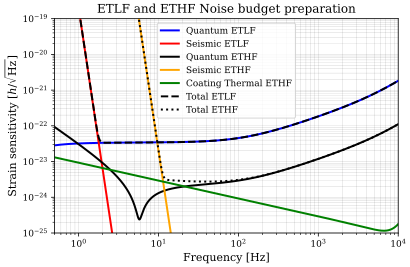

In [27]:
# Group incoherent noises by type (quadrature sum: sqrt(A^2 + B^2 + ...))
output_key = "AS_port.DC.o"
S_seismic_ETLF = np.sqrt(sum(
    sol_lf.out[output_key][:, sol_lf.noises.index(n)]**2
    for n in sol_lf.noises if "seismic" in n
))

S_seismic_ETHF = np.sqrt(sum(
    sol_hf.out[output_key][:, sol_hf.noises.index(n)]**2
    for n in sol_hf.noises if "seismic" in n
))

S_coating_ETHF = np.sqrt(sum(
    sol_hf.out[output_key][:, sol_hf.noises.index(n)]**2
    for n in sol_hf.noises if "coating" in n
))

#Extra noises can be added here

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# ETLF Noise budget plot
ax.loglog(f, S_qn_ETLF, label="Quantum ETLF", linewidth=2)
ax.loglog(f, S_seismic_ETLF, label="Seismic ETLF", linewidth=2)
#ax.loglog(f, S_thermal, label="Thermal", linewidth=2)

# ETHF Noise budget plot
ax.loglog(f, S_qn_ETHF, label="Quantum ETHF", linewidth=2)
ax.loglog(f, S_seismic_ETHF, label="Seismic ETHF", linewidth=2)
ax.loglog(f, S_coating_ETHF, label="Coating Thermal ETHF", linewidth=2)

#total = np.sqrt(S_quantum**2 + S_seismic**2 + S_thermal**2+ etc)
total_ETFL = np.sqrt(S_qn_ETLF**2 + S_seismic_ETLF**2)
total_ETHL = np.sqrt(S_qn_ETHF**2 + S_seismic_ETHF**2 + S_coating_ETHF**2)
ax.loglog(f, total_ETFL, label="Total ETLF", color='k', linewidth=2, linestyle='--')
ax.loglog(f, total_ETHL, label="Total ETHF", color='k', linewidth=2, linestyle=':')

ax.set_ylim(1e-25, 1e-19)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Strain sensitivity [$h/\\sqrt{\\mathrm{Hz}}$]")
ax.set_title("ETLF and ETHF Noise budget preparation")
ax.legend()
fig.tight_layout()
plt.show()